# Deteccion de Objetos con RF-DETR

La deteccion de objetos es una tarea fundamental en vision artificial. Consiste en encontrar objetos en imagenes y dibujar cajas alrededor de ellos (bounding boxes) indicando que objeto es.

**Diferencia con clasificacion:**
- Clasificacion: "Esta imagen completa contiene un gato" → 1 etiqueta
- Deteccion: "Hay 3 gatos en las posiciones X, Y, Z" → multiples boxes con etiquetas

En este notebook veremos RF-DETR, un detector moderno basado en Transformers.

## Evolucion de los Detectores

### Arquitecturas Clasicas (CNN):
- **R-CNN, Fast R-CNN, Faster R-CNN**: Detectores en dos etapas (propuestas + clasificacion)
- **YOLO (You Only Look Once)**: Detector en una etapa, muy rapido
  - YOLOv3, YOLOv4, YOLOv5, YOLOv235894... (muchas versiones)
  - Ventaja: velocidad (tiempo real en video)
  - Desventaja: arquitectura compleja con muchos "trucos", LICENCIA!!

### Arquitecturas Modernas (Transformers):
- **DETR (DEtection TRansformer)**: Primer detector con Transformers
- **RT-DETR / RF-DETR**: Version rapida y eficiente de DETR
  - Ventaja: arquitectura limpia, sin anchors ni NMS
  - Ventaja: precision SOTA (State of the Art), LICENCIAS 

**Por que Transformers?** Los Transformers (la misma arquitectura de ChatGPT) tambien funcionan muy bien en vision. Son mas flexibles y aprenden mejor las relaciones entre objetos.

## Configuracion e Imports

In [29]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO
import warnings
warnings.filterwarnings("ignore") # evitar warnings innecesarios

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch version: {torch.__version__}, usando: {device}")

torch version: 2.6.0+cu124, usando: cuda


In [30]:
# Instalar libreria RFDETR (roboflow DETR)
try:
    from rfdetr import RFDETRSmall
    print("RFDETR importado!")
except ImportError:
    print("Instalando rfdetr...")
    %pip install rfdetr
    from rfdetr import RFDETRSmall

RFDETR importado!


## Carga del Modelo RF-DETR

RF-DETR tiene varios tamaños: l (large), m (medium), s (small), x (extra large). Usaremos `rtdetr-l.pt` que da buen balance.

El modelo viene pre-entrenado en **COCO dataset** con **80 categorias** de objetos comunes: personas, coches, animales, muebles, electronica, etc.

In [ ]:
from rfdetr.util.coco_classes import COCO_CLASSES

model = RFDETRSmall()

# model.optimize_for_inference(compile=False)

print("Modelo RF-DETR cargado")
print(f"Clases disponibles: {len(COCO_CLASSES)} categorias COCO")
print(COCO_CLASSES)

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Modelo RF-DETR cargado
Clases disponibles: 80 categorias COCO
{1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane', 6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light', 11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench', 16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 27: 'backpack', 28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket

## Carga de Imagenes de Ejemplo

In [22]:
# Cargar imagenes desde GitHub
url_cars = "https://github.com/sergiovillanueva/prompt_to_mask/raw/master/assets/cars.jpg"
image_cars = Image.open(BytesIO(requests.get(url_cars).content)).convert("RGB")

url_person = "https://github.com/sergiovillanueva/prompt_to_mask/raw/master/assets/person_cars.jpg"
image_person = Image.open(BytesIO(requests.get(url_person).content)).convert("RGB")

print("Imagenes cargadas")

Imagenes cargadas


## Deteccion de Objetos

Vamos a detectar objetos en las imagenes. RF-DETR devolvera:
- **Bounding boxes**: coordenadas [x1, y1, x2, y2]
- **Clases**: que objeto es (coche, persona, etc.)
- **Confianza**: probabilidad de 0 a 1

Detections(xyxy=array([[  54.691063,  204.54045 ,  668.5378  ,  459.49387 ],
       [ 682.2696  ,  239.7741  , 1153.1152  ,  409.22565 ]],
      dtype=float32), mask=None, confidence=array([0.95880216, 0.93293977], dtype=float32), class_id=array([3, 3]), tracker_id=None, data={}, metadata={})

Detectados 2 objetos:

  car: 0.96 en [54, 204, 668, 459]
  car: 0.93 en [682, 239, 1153, 409]


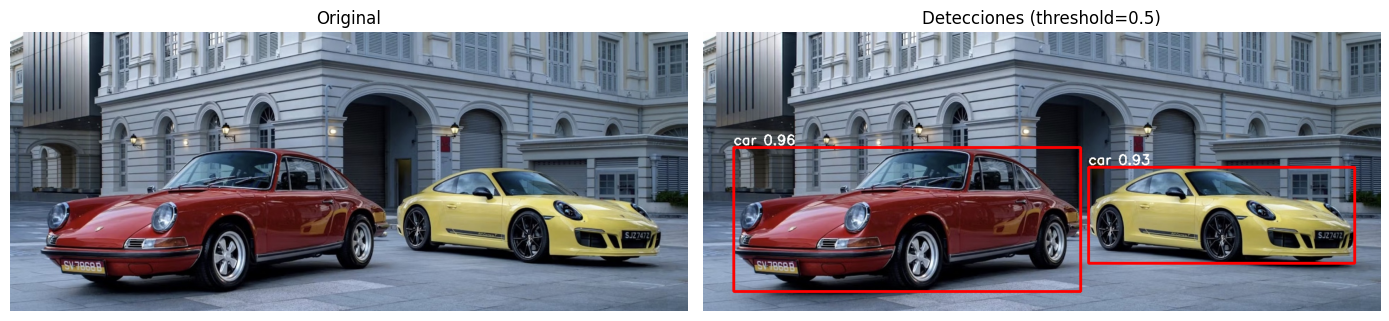

Detections(xyxy=array([[ 3.64099091e+02,  8.63349457e+01,  4.87579163e+02,
         3.27467499e+02],
       [ 2.00814743e+02,  1.10130249e+02,  3.61045807e+02,
         2.03289047e+02],
       [ 7.97828579e+00,  1.14223892e+02,  1.49641891e+02,
         2.12998871e+02],
       [ 1.13942574e+02,  1.07970665e+02,  2.06311142e+02,
         1.79929886e+02],
       [-4.62473184e-03,  1.15384499e+02,  3.16176949e+01,
         1.86025497e+02],
       [ 5.13554199e+02,  9.44257278e+01,  5.71182312e+02,
         1.19191643e+02],
       [ 5.82897797e+01,  1.03849976e+02,  1.25457382e+02,
         1.22779083e+02],
       [ 2.09046135e+01,  1.02580063e+02,  6.79673004e+01,
         1.17664825e+02],
       [ 4.39522430e+02,  1.29684494e+02,  4.86325958e+02,
         2.55858688e+02],
       [ 4.93256958e+02,  9.75649796e+01,  5.23692871e+02,
         1.17200569e+02]], dtype=float32), mask=None, confidence=array([0.9665855 , 0.9483119 , 0.93766576, 0.92399013, 0.7708232 ,
       0.72673845, 0.6983387

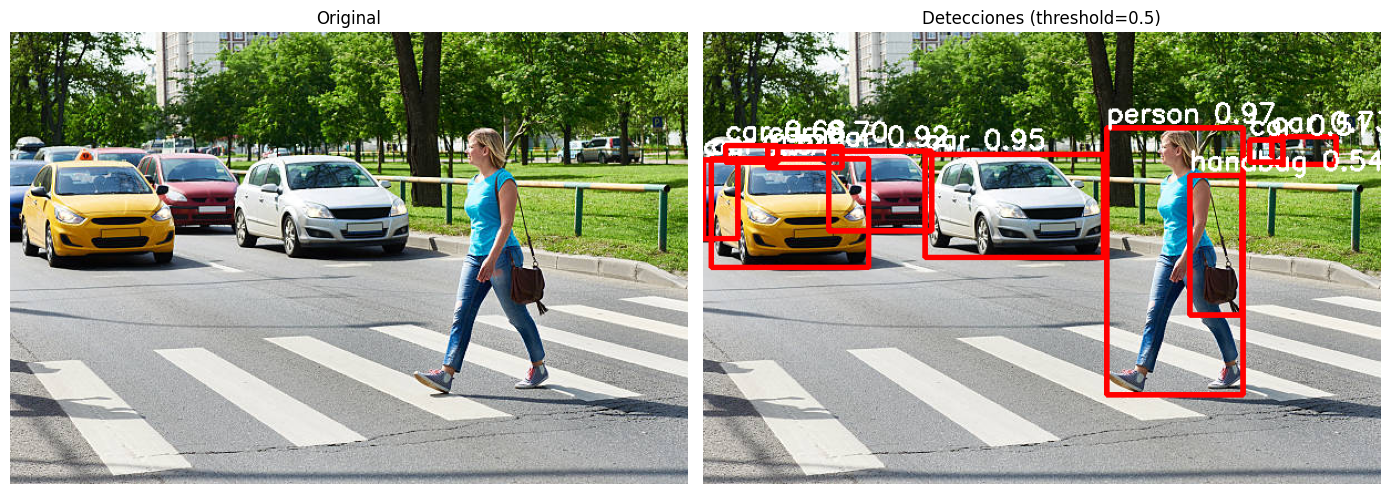

In [23]:
def detect_objects(image, conf_threshold=0.5):
    """Detecta objetos usando RF-DETR"""
    
    # Convertir PIL a numpy
    img_array = np.array(image)
    
    detections = model.predict(img_array, threshold=conf_threshold)
    
    print(detections)
    
    # Obtener detecciones desde la estructura Detections
    boxes = detections.xyxy  # Coordenadas [x1, y1, x2, y2]
    classes = detections.class_id  # IDs de clases
    scores = detections.confidence  # Confianza
    
    print(f"\nDetectados {len(boxes)} objetos:\n")
    
    # Dibujar detecciones
    img_result = img_array.copy()
    
    for box, cls, score in zip(boxes, classes, scores):
        x1, y1, x2, y2 = map(int, box)
        class_name = COCO_CLASSES[int(cls)]
        
        print(f"  {class_name}: {score:.2f} en [{x1}, {y1}, {x2}, {y2}]")
        
        # Dibujar box y texto
        cv2.rectangle(img_result, (x1, y1), (x2, y2), (255, 0, 0), 3)  # Azul
        text = f"{class_name} {score:.2f}"
        cv2.putText(img_result, text, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].imshow(img_array)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(img_result)
    axes[1].set_title(f"Detecciones (threshold={conf_threshold})")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return boxes, classes, scores

# Ejemplo: detectar coches
boxes, classes, scores = detect_objects(image_cars, conf_threshold=0.5);
boxes, classes, scores = detect_objects(image_person, conf_threshold=0.5)

## Experimentar con Thresholds

El threshold de confianza controla cuantas detecciones vemos:
- **Threshold alto (0.7-0.9)**: Solo detecciones muy seguras, menos false positives
- **Threshold bajo (0.2-0.4)**: Mas detecciones, pero puede haber errores

Vamos a probar con diferentes valores:

## Limitaciones de Modelos Supervisados

RF-DETR esta entrenado en COCO que tiene 80 categorias. Esto significa:

### ✅ Detecta bien:
- Objetos comunes: personas, coches, animales, muebles
- Objetos de la vida diaria

### ❌ NO detecta:
- Objetos industriales especificos (tornillos, tuercas, componentes electronicos)
- Objetos raros o muy especializados
- Defectos de fabricacion
- Cualquier cosa que no este en las 80 categorias COCO

**Solucion**: Usar modelos fundacionales como **Grounding DINO** o **Qwen2.5-VL** que pueden detectar objetos con descripcion de texto sin estar entrenados especificamente para ello. Los veremos en el proximo notebook.

## Ver todas las clases COCO

Veamos que objetos puede detectar el modelo:

In [24]:
# Mostrar todas las clases disponibles
print("Clases COCO que RF-DETR puede detectar:\n")
for idx, name in COCO_CLASSES.items():
    print(f"{idx:2d}: {name}")

Clases COCO que RF-DETR puede detectar:

 1: person
 2: bicycle
 3: car
 4: motorcycle
 5: airplane
 6: bus
 7: train
 8: truck
 9: boat
10: traffic light
11: fire hydrant
13: stop sign
14: parking meter
15: bench
16: bird
17: cat
18: dog
19: horse
20: sheep
21: cow
22: elephant
23: bear
24: zebra
25: giraffe
27: backpack
28: umbrella
31: handbag
32: tie
33: suitcase
34: frisbee
35: skis
36: snowboard
37: sports ball
38: kite
39: baseball bat
40: baseball glove
41: skateboard
42: surfboard
43: tennis racket
44: bottle
46: wine glass
47: cup
48: fork
49: knife
50: spoon
51: bowl
52: banana
53: apple
54: sandwich
55: orange
56: broccoli
57: carrot
58: hot dog
59: pizza
60: donut
61: cake
62: chair
63: couch
64: potted plant
65: bed
67: dining table
70: toilet
72: tv
73: laptop
74: mouse
75: remote
76: keyboard
77: cell phone
78: microwave
79: oven
80: toaster
81: sink
82: refrigerator
84: book
85: clock
86: vase
87: scissors
88: teddy bear
89: hair drier
90: toothbrush


## Aplicacion Industrial: Contar Objetos

En aplicaciones industriales es comun necesitar contar objetos. Vamos a crear una funcion que cuente automaticamente.

Conteo de objetos:

  car: 2


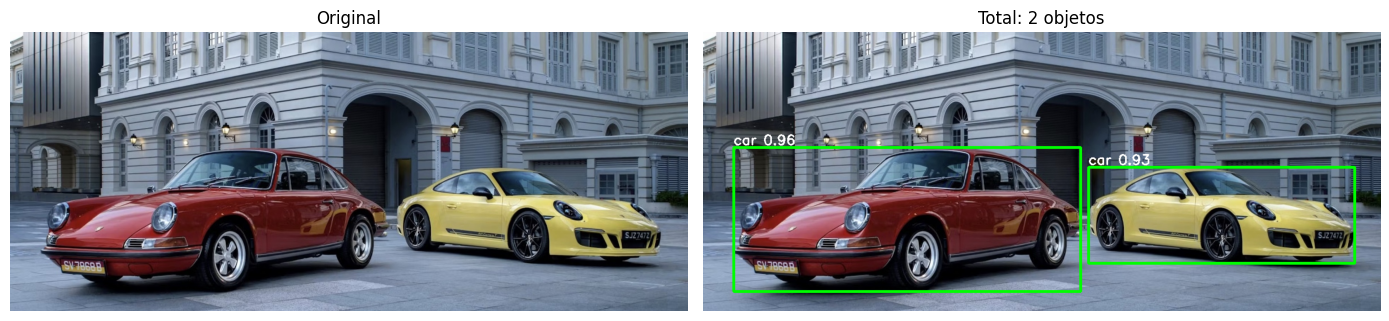

In [25]:
def count_objects_by_class(image, conf_threshold=0.5):
    """Cuenta objetos agrupados por clase"""
    
    img_array = np.array(image)
    detections = model.predict(img_array, threshold=conf_threshold)
    
    # Obtener detecciones
    boxes = detections.xyxy
    classes = detections.class_id
    scores = detections.confidence
    
    # Contar por clase
    from collections import Counter
    class_counts = Counter([COCO_CLASSES[int(c)] for c in classes])
    
    print("Conteo de objetos:\n")
    for class_name, count in class_counts.most_common():
        print(f"  {class_name}: {count}")
    
    # Dibujar detecciones
    img_result = img_array.copy()
    
    for box, cls, score in zip(boxes, classes, scores):
        x1, y1, x2, y2 = map(int, box)
        class_name = COCO_CLASSES[int(cls)]
        
        # Dibujar box y texto
        cv2.rectangle(img_result, (x1, y1), (x2, y2), (0, 255, 0), 3)  # Verde
        text = f"{class_name} {score:.2f}"
        cv2.putText(img_result, text, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].imshow(img_array)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(img_result)
    axes[1].set_title(f"Total: {len(classes)} objetos")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

# Contar objetos en imagen
counts = count_objects_by_class(image_cars)

## Ejercicio: Detecta objetos en tu imagen

Prueba el detector con tus propias imagenes. Puede ser:
- Foto de tu escritorio (detectara laptop, mouse, teclado, etc.)
- Foto de la calle (coches, personas, semaforos)
- Cualquier imagen con objetos de COCO

In [26]:
# EJERCICIO: Tu imagen aqui

# Opcion 1: Desde URL
# tu_url = "https://..."  # <- URL de tu imagen
# tu_imagen = Image.open(BytesIO(requests.get(tu_url).content)).convert("RGB")

# Opcion 2: Desde archivo
# tu_imagen = Image.open("ruta/a/tu/imagen.jpg").convert("RGB")

# Detectar
# detect_objects(tu_imagen, conf_threshold=0.5)


## Ejercicio Extra (Comodin): Filtrar por clase

Modifica la funcion `detect_objects()` para que solo muestre detecciones de ciertas clases.

Por ejemplo: solo mostrar "car" y "truck", ignorando el resto.

**Pista**: Filtra las boxes antes de dibujarlas comprobando el nombre de la clase.

In [27]:
# EJERCICIO EXTRA: Deteccion filtrada por clases
def detect_only(image, allowed_classes, conf_threshold=0.5):
    """
    Detecta solo las clases especificadas.
    allowed_classes: lista de nombres de clases, ej: ['car', 'person']
    """
    # Tu codigo aqui...
    pass

# Prueba:
# detect_only(image_cars, allowed_classes=['car'], conf_threshold=0.5)


## Resumen

En este notebook hemos aprendido:

✅ Que es la deteccion de objetos y para que sirve  
✅ Diferencia entre arquitecturas clasicas (YOLO) y modernas (RF-DETR)  
✅ Por que Transformers funcionan bien en vision  
✅ Usar RF-DETR para detectar objetos  
✅ Configurar thresholds de confianza  
✅ Limitaciones de modelos supervisados (solo 80 clases COCO)  
✅ Contar objetos automaticamente  

**Siguiente paso**: En el proximo notebook veremos Hugging Face Hub para buscar y descargar modelos facilmente.

**Contacto**: Si tienes dudas puedes escribirme un email!